
  TETHER (USDT) vs BIST 100 — IMPACT ANALYSIS (ENHANCED)

  Detected files:
    BIST 100 : ./BIST 100 Historical Data.csv
    Tether   : ./Tether USDt Historical Data_crypto.csv

  Data loaded: 87 overlapping trading days (weekends dropped)
  Period : Jan 2019 → Mar 2026

      Date  USDT_Return  BIST_Return
2019-01-01      -0.0046       0.1403
2019-02-01       0.0005       0.0044
2019-03-01       0.0053      -0.1028
2019-04-01       0.0201       0.0174
2019-05-01      -0.0215      -0.0506
  ...

  SECTION 2 — DESCRIPTIVE STATISTICS
             Count     Mean      Std     Min     25%     50%      75%     Max
USDT_Return   87.0  0.00002  0.00367 -0.0215 -0.0006  0.0000  0.00040  0.0201
BIST_Return   87.0  0.03460  0.08773 -0.1543 -0.0308  0.0265  0.08395  0.2531

  Pearson Correlation (USDT vs BIST 100): 0.0082


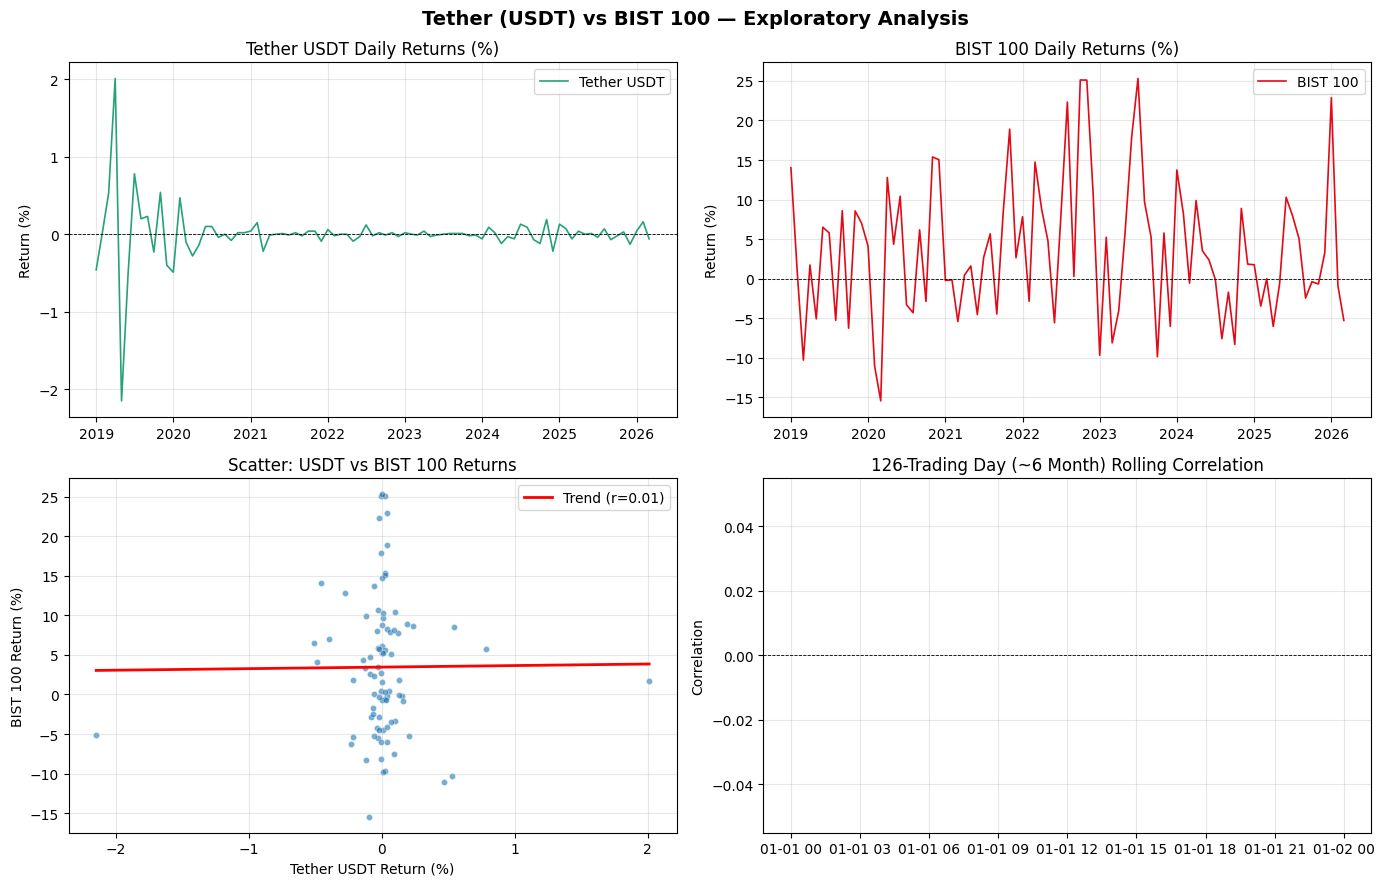


  [Chart saved: 01_exploratory_analysis.png]

  APPROACH 1 — STATIC OLS REGRESSION

  Step 3 — Means
    Average USDT Return     (X̄) = 0.00184%
    Average BIST 100 Return (Ȳ) = 3.45977%

  Step 4 — Slope β
    β = 0.1949
    → For every 1% rise in USDT, BIST 100 changes by ~0.1949%

  Step 5 — Intercept α = 0.034594

  Step 6 — Regression Equation
    BIST_Return = 0.034594 + 0.1949 × USDT_Return

  Step 7 — t-Test for Statistical Significance
    SE(β)       = 2.5924
    t-statistic = 0.0752
    p-value     = 0.9402
    ✘ NOT significant — Fail to reject H₀

  Step 8 — Goodness of Fit
    R² = 0.0001  (0.01% of BIST 100 variation explained by USDT)

  ── Full OLS Summary ──
                            OLS Regression Results                            
Dep. Variable:            BIST_Return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                  0.0056

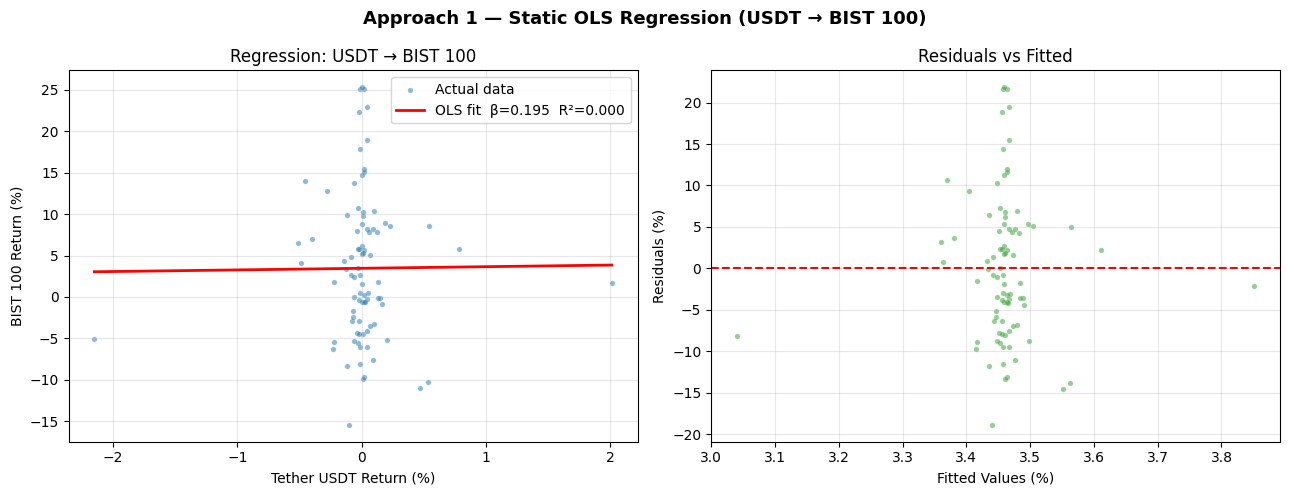


  [Chart saved: 02_approach1_static_ols.png]

  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION

  Step 2 — ADF Stationarity Test
    USDT Return               | ADF stat =  -3.442 | p = 0.0096 | ✔ Stationary
    BIST 100 Return           | ADF stat =  -7.860 | p = 0.0000 | ✔ Stationary

  Step 3 — Autocorrelation of BIST 100 Returns
    Lag-1 autocorrelation: 0.1556
    Lag-2 autocorrelation: -0.0198
    ⚠ Notable autocorrelation — lagged term is essential for model validity

  Step 4 & 5 — Building Dynamic Regression Model
    Model: BIST_t = α + β×USDT_t + γ×BIST_(t-1)

    Estimated equation:
    BIST_t = 0.02766 + 0.9425×USDT_t + 0.1584×BIST_(t-1)

  Step 6 — Statistical Significance
    Crypto effect (β): coef=0.9425  t=0.362  p=0.7179  ✘ Not significant
    Lag effect   (γ): coef=0.1584  t=1.461  p=0.1478  ✘ Not significant

    R² (dynamic model) = 0.0258
    Adj. R²            = 0.0023

  Step 7 — Granger Causality Test
    H₀: USDT returns do NOT Granger-cause BIST 100 returns
 

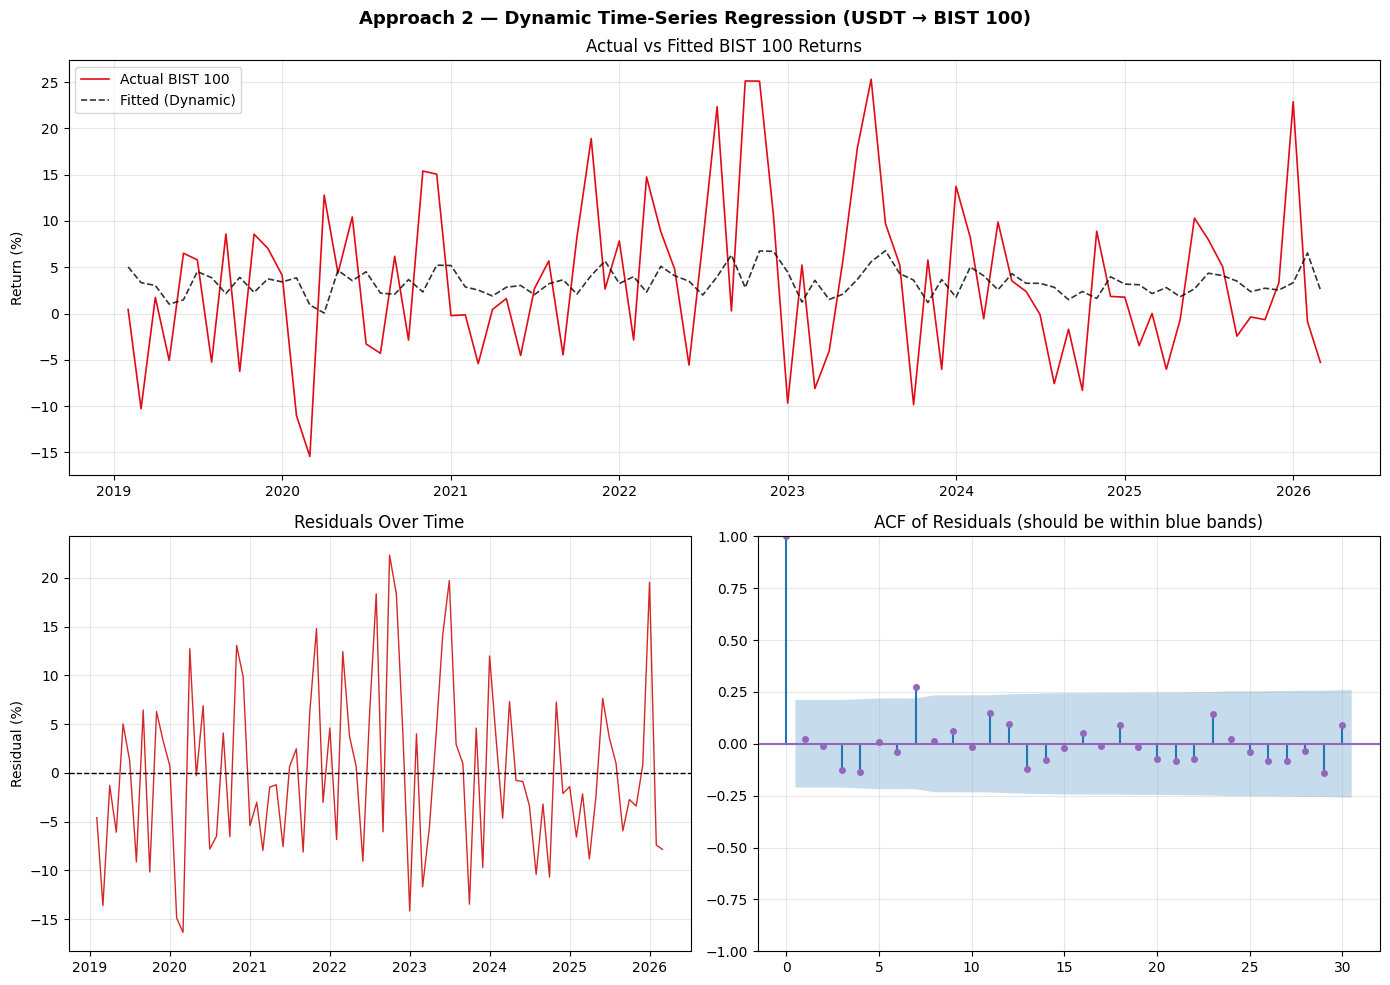


  [Chart saved: 03_approach2_dynamic.png]

  FINAL COMPARISON SUMMARY
                     Approach 1 (Static)      Approach 2 (Dynamic)
Method                    OLS Regression  Dynamic Regression + Lag
Crypto Coeff (β)                  0.1949                    0.9425
Lag Term (γ)                Not included                    0.1584
p-value (crypto)                  0.9402                    0.7179
R²                                0.0001                    0.0258
Accounts for Memory?                  No                       Yes


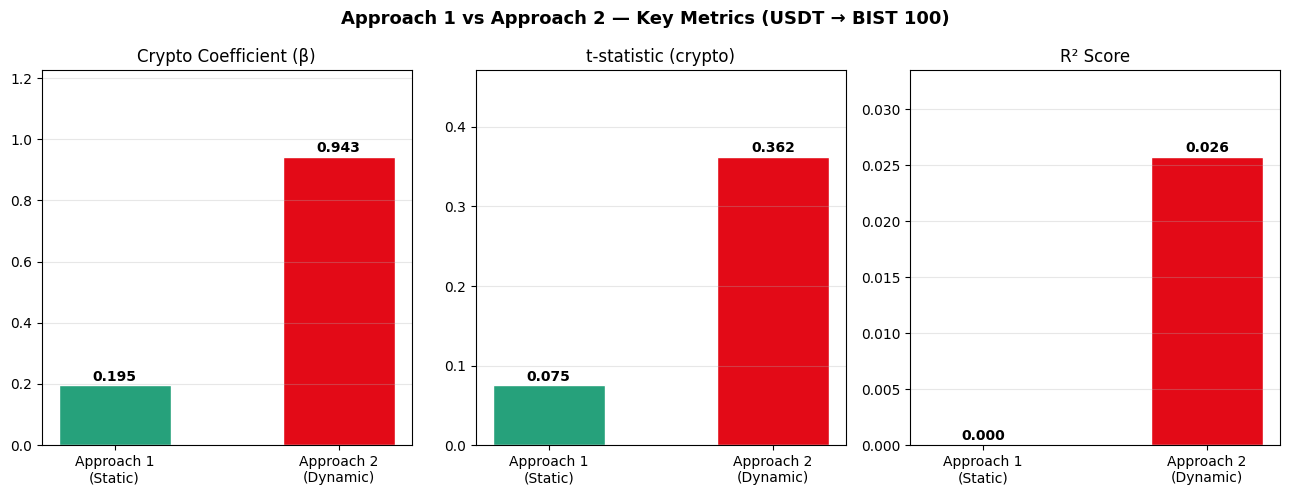


  [Chart saved: 04_comparison_summary.png]

  CONCLUSION & ECONOMETRIC CONSIDERATIONS

  Analysis of Tether (USDT) impact on BIST 100 Index:

  ▸ Approach 1 (Static OLS):
      β = 0.1949 — a 1% USDT change correlates with ~0.195% BIST 100 change
      R² = 0.0001
      Result: NOT SIGNIFICANT

  ▸ Approach 2 (Dynamic with Lag):
      β = 0.9425 — immediate effect after controlling for momentum
      γ = 0.1584 — 15.8% of prior period's BIST return persists
      R² = 0.0258
      Result: NOT SIGNIFICANT

  CRITICAL LOGICAL CONSIDERATIONS:
  1. The "Stablecoin Peg" Reality: The global price of USDT is mathematically pegged 
     to $1.00. The "returns" measured here are micro-fluctuations (fractions of a cent) 
     driven by global crypto market arbitrage, NOT by Turkish market dynamics. 
  2. BIST Drivers: The BIST 100 is highly volatile and driven heavily by the 
     Turkish Central Bank's monetary policy, inflation metrics, and the devaluation 
     of the Turkish Lira against th

In [ ]:
# ============================================================
#   TETHER (USDT) vs BIST 100 — IMPACT ANALYSIS (ENHANCED)
# ============================================================


import subprocess
subprocess.run(["pip", "install", "statsmodels", "scipy", "pandas", "numpy", "matplotlib", "-q"])


import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings("ignore")


search_dirs = ["/content", "/root", "."]
csv_files = []
for d in search_dirs:
    csv_files.extend(glob.glob(os.path.join(d, "*.csv")))

csv_files = list(set(csv_files))

if len(csv_files) < 2:
    raise FileNotFoundError(
        f"Found only {len(csv_files)} CSV file(s). "
        "Please ensure both BIST 100 and Tether CSV files are present in the Colab session "
        "before running this script (use the file browser on the left sidebar)."
    )


BIST_FILE  = next((f for f in csv_files if "BIST" in os.path.basename(f) or "bist" in os.path.basename(f)), None)
USDT_FILE  = next((f for f in csv_files if "Tether" in os.path.basename(f) or "tether" in os.path.basename(f)
                                        or "USDt" in os.path.basename(f) or "USDT" in os.path.basename(f)), None)


if BIST_FILE is None or USDT_FILE is None:
    remaining = [f for f in csv_files if f not in (BIST_FILE, USDT_FILE)]
    if BIST_FILE is None and remaining:
        BIST_FILE = remaining.pop(0)
    if USDT_FILE is None and remaining:
        USDT_FILE = remaining.pop(0)

if BIST_FILE is None or USDT_FILE is None:
    raise FileNotFoundError(
        "Could not identify both BIST 100 and Tether CSV files. "
        f"Files found: {csv_files}\n"
        "Please ensure filenames contain 'BIST' and 'Tether'/'USDt'."
    )

print("\n" + "=" * 65)
print("  TETHER (USDT) vs BIST 100 — IMPACT ANALYSIS (ENHANCED)")
print("=" * 65)
print(f"\n  Detected files:")
print(f"    BIST 100 : {BIST_FILE}")
print(f"    Tether   : {USDT_FILE}")

# ============================================================
# DATA LOADING & CLEANING
# ============================================================

def load_and_clean(filepath, label):
    df = pd.read_csv(filepath, thousands=",")
    df.columns = df.columns.str.strip()

    df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=False)
    df = df.sort_values("Date").reset_index(drop=True)


    df["Return"] = (
        df["Change %"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .astype(float)
        / 100
    )
    df = df[["Date", "Return"]].rename(columns={"Return": label})
    return df

usdt = load_and_clean(USDT_FILE, "USDT_Return")
bist = load_and_clean(BIST_FILE, "BIST_Return")

data = pd.merge(usdt, bist, on="Date", how="inner")
data = data.sort_values("Date").dropna().reset_index(drop=True)

print(f"\n  Data loaded: {len(data)} overlapping trading days (weekends dropped)")
print(f"  Period : {data['Date'].min().strftime('%b %Y')} → {data['Date'].max().strftime('%b %Y')}\n")
print(data[["Date", "USDT_Return", "BIST_Return"]].head().to_string(index=False))
print("  ...")

# ============================================================
# SECTION 2: DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "=" * 65)
print("  SECTION 2 — DESCRIPTIVE STATISTICS")
print("=" * 65)

desc = data[["USDT_Return", "BIST_Return"]].describe().T
desc.columns = ["Count", "Mean", "Std", "Min", "25%", "50%", "75%", "Max"]
print(desc.round(5).to_string())

corr = data["USDT_Return"].corr(data["BIST_Return"])
print(f"\n  Pearson Correlation (USDT vs BIST 100): {corr:.4f}")


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Tether (USDT) vs BIST 100 — Exploratory Analysis", fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.plot(data["Date"], data["USDT_Return"] * 100, color="#26A17B", label="Tether USDT", linewidth=1.2) # Tether Green
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("Tether USDT Daily Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(data["Date"], data["BIST_Return"] * 100, color="#E30A17", label="BIST 100", linewidth=1.2) # Turkey Red
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("BIST 100 Daily Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(data["USDT_Return"] * 100, data["BIST_Return"] * 100,
           alpha=0.6, color="#1f77b4", edgecolors="white", linewidth=0.4, s=20)

if data["USDT_Return"].std() > 1e-6:
    m, b = np.polyfit(data["USDT_Return"], data["BIST_Return"], 1)
    x_line = np.linspace(data["USDT_Return"].min(), data["USDT_Return"].max(), 100)
    ax.plot(x_line * 100, (m * x_line + b) * 100, color="red", linewidth=2, label=f"Trend (r={corr:.2f})")
ax.set_xlabel("Tether USDT Return (%)")
ax.set_ylabel("BIST 100 Return (%)")
ax.set_title("Scatter: USDT vs BIST 100 Returns")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 1]

roll_corr = data["USDT_Return"].rolling(126).corr(data["BIST_Return"])
ax.plot(data["Date"], roll_corr, color="#800080", linewidth=1.8)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("126-Trading Day (~6 Month) Rolling Correlation")
ax.set_ylabel("Correlation")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("01_exploratory_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 01_exploratory_analysis.png]")

# ============================================================
# APPROACH 1: STATIC OLS REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 1 — STATIC OLS REGRESSION")
print("=" * 65)

X = data["USDT_Return"]
Y = data["BIST_Return"]

x_mean = X.mean()
y_mean = Y.mean()
print(f"\n  Step 3 — Means")
print(f"    Average USDT Return     (X̄) = {x_mean*100:.5f}%")
print(f"    Average BIST 100 Return (Ȳ) = {y_mean*100:.5f}%")

numerator   = ((X - x_mean) * (Y - y_mean)).sum()
denominator = ((X - x_mean) ** 2).sum()
beta        = numerator / denominator if denominator != 0 else 0
print(f"\n  Step 4 — Slope β")
print(f"    β = {beta:.4f}")
print(f"    → For every 1% rise in USDT, BIST 100 changes by ~{beta:.4f}%")

alpha = y_mean - beta * x_mean
print(f"\n  Step 5 — Intercept α = {alpha:.6f}")

print(f"\n  Step 6 — Regression Equation")
print(f"    BIST_Return = {alpha:.6f} + {beta:.4f} × USDT_Return")

X_const   = sm.add_constant(X)
ols_model = sm.OLS(Y, X_const).fit()
se_beta   = ols_model.bse.get("USDT_Return", np.nan)
t_stat    = ols_model.tvalues.get("USDT_Return", np.nan)
p_value   = ols_model.pvalues.get("USDT_Return", np.nan)

print(f"\n  Step 7 — t-Test for Statistical Significance")
print(f"    SE(β)       = {se_beta:.4f}")
print(f"    t-statistic = {t_stat:.4f}")
print(f"    p-value     = {p_value:.4f}")

if pd.notna(t_stat) and abs(t_stat) > 2.0:
    print(f"    ✔ SIGNIFICANT — Reject H₀ (|t| = {t_stat:.2f} > 2.0)")
else:
    print(f"    ✘ NOT significant — Fail to reject H₀")

r_squared = ols_model.rsquared
print(f"\n  Step 8 — Goodness of Fit")
print(f"    R² = {r_squared:.4f}  ({r_squared*100:.2f}% of BIST 100 variation explained by USDT)")

print(f"\n  ── Full OLS Summary ──")
print(ols_model.summary())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Approach 1 — Static OLS Regression (USDT → BIST 100)", fontsize=13, fontweight="bold")

ax = axes[0]
ax.scatter(X * 100, Y * 100, alpha=0.5, color="#1f77b4", edgecolors="white", linewidth=0.2, s=15, label="Actual data")
x_fit = np.linspace(X.min(), X.max(), 200)
y_fit = alpha + beta * x_fit
ax.plot(x_fit * 100, y_fit * 100, color="red", linewidth=2, label=f"OLS fit  β={beta:.3f}  R²={r_squared:.3f}")
ax.set_xlabel("Tether USDT Return (%)")
ax.set_ylabel("BIST 100 Return (%)")
ax.set_title("Regression: USDT → BIST 100")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
residuals = ols_model.resid
ax.scatter(ols_model.fittedvalues * 100, residuals * 100, alpha=0.5, color="#2ca02c", edgecolors="white", linewidth=0.2, s=15)
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Fitted Values (%)")
ax.set_ylabel("Residuals (%)")
ax.set_title("Residuals vs Fitted")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("02_approach1_static_ols.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 02_approach1_static_ols.png]")

# ============================================================
# APPROACH 2: DYNAMIC TIME-SERIES REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION")
print("=" * 65)

print("\n  Step 2 — ADF Stationarity Test")
for series, name in [(data["USDT_Return"], "USDT Return"),
                     (data["BIST_Return"],  "BIST 100 Return")]:
    if series.std() > 1e-6:
        adf_result = adfuller(series.dropna())
        stat, pval = adf_result[0], adf_result[1]
        flag = "✔ Stationary" if pval < 0.05 else "⚠ Non-Stationary"
        print(f"    {name:25s} | ADF stat = {stat:7.3f} | p = {pval:.4f} | {flag}")
    else:
        print(f"    {name:25s} | Variance too low for reliable ADF test (USDT Peg behavior)")

print("\n  Step 3 — Autocorrelation of BIST 100 Returns")
lag1_autocorr = data["BIST_Return"].autocorr(lag=1)
lag2_autocorr = data["BIST_Return"].autocorr(lag=2)
print(f"    Lag-1 autocorrelation: {lag1_autocorr:.4f}")
print(f"    Lag-2 autocorrelation: {lag2_autocorr:.4f}")
if abs(lag1_autocorr) > 0.1:
    print("    ⚠ Notable autocorrelation — lagged term is essential for model validity")
else:
    print("    Low autocorrelation — lagged term adds robustness")

print("\n  Step 4 & 5 — Building Dynamic Regression Model")
print("    Model: BIST_t = α + β×USDT_t + γ×BIST_(t-1)")

data_dyn = data.copy()
data_dyn["BIST_Lag1"] = data_dyn["BIST_Return"].shift(1)
data_dyn = data_dyn.dropna().reset_index(drop=True)

Y_dyn = data_dyn["BIST_Return"]
X_dyn = sm.add_constant(data_dyn[["USDT_Return", "BIST_Lag1"]])

dyn_model = sm.OLS(Y_dyn, X_dyn).fit()

alpha_dyn = dyn_model.params["const"]
beta_dyn  = dyn_model.params.get("USDT_Return", 0)
gamma_dyn = dyn_model.params.get("BIST_Lag1", 0)

print(f"\n    Estimated equation:")
print(f"    BIST_t = {alpha_dyn:.5f} + {beta_dyn:.4f}×USDT_t + {gamma_dyn:.4f}×BIST_(t-1)")

print(f"\n  Step 6 — Statistical Significance")
for var in ["USDT_Return", "BIST_Lag1"]:
    if var in dyn_model.tvalues:
        t  = dyn_model.tvalues[var]
        p  = dyn_model.pvalues[var]
        label = "Crypto effect (β)" if var == "USDT_Return" else "Lag effect   (γ)"
        sig = "✔ Significant" if p < 0.05 else "✘ Not significant"
        print(f"    {label}: coef={dyn_model.params[var]:.4f}  t={t:.3f}  p={p:.4f}  {sig}")

print(f"\n    R² (dynamic model) = {dyn_model.rsquared:.4f}")
print(f"    Adj. R²            = {dyn_model.rsquared_adj:.4f}")

print("\n  Step 7 — Granger Causality Test")
print("    H₀: USDT returns do NOT Granger-cause BIST 100 returns")
granger_data = data[["BIST_Return", "USDT_Return"]].dropna()

if granger_data["USDT_Return"].var() > 1e-8:
    max_allowable_lag = max(1, int((len(granger_data) - 1) / 3) - 1)
    granger_maxlag    = min(5, max_allowable_lag)
    print(f"    Sample size: {len(granger_data)} obs → testing up to lag={granger_maxlag} days")
    try:
        gc_results = grangercausalitytests(granger_data, maxlag=granger_maxlag, verbose=False)
        for lag, res in gc_results.items():
            f_stat = res[0]["ssr_ftest"][0]
            p_gc   = res[0]["ssr_ftest"][1]
            flag   = "✔ Granger-causes" if p_gc < 0.05 else "✘ No causal effect"
            print(f"    Lag {lag} day(s): F={f_stat:.3f}  p={p_gc:.4f}  → {flag}")
    except Exception as e:
        print(f"    Granger Causality failed (likely due to insufficient variance in USDT): {e}")
else:
    print("    Skipping Granger Causality due to near-zero variance in USDT (stablecoin peg).")

print("\n  Step 8 — Diagnostic Checks")
dw_stat = durbin_watson(dyn_model.resid)
print(f"    Durbin-Watson statistic = {dw_stat:.4f}")
if 1.5 < dw_stat < 2.5:
    print("    ✔ No significant autocorrelation in residuals (DW ≈ 2.0)")
else:
    print("    ⚠ Possible residual autocorrelation detected")

print(f"\n  ── Full Dynamic Model Summary ──")
print(dyn_model.summary())

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Approach 2 — Dynamic Time-Series Regression (USDT → BIST 100)", fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(data_dyn["Date"], Y_dyn * 100, color="#E30A17", linewidth=1.2, label="Actual BIST 100")
ax1.plot(data_dyn["Date"], dyn_model.fittedvalues * 100, color="black", linestyle="--", linewidth=1.2, alpha=0.8, label="Fitted (Dynamic)")
ax1.set_title("Actual vs Fitted BIST 100 Returns")
ax1.set_ylabel("Return (%)")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(data_dyn["Date"], dyn_model.resid * 100, color="#d62728", linewidth=1.0)
ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_title("Residuals Over Time")
ax2.set_ylabel("Residual (%)")
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
acf_lags = min(30, len(dyn_model.resid) // 2 - 1)
plot_acf(dyn_model.resid, lags=acf_lags, ax=ax3, color="#9467bd", markersize=4)
ax3.set_title("ACF of Residuals (should be within blue bands)")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("03_approach2_dynamic.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 03_approach2_dynamic.png]")

# ============================================================
# FINAL SUMMARY & ECONOMETRIC CONSIDERATIONS
# ============================================================

print("\n" + "=" * 65)
print("  FINAL COMPARISON SUMMARY")
print("=" * 65)

p_val_static  = p_value if pd.notna(p_value) else 1.0
p_val_dynamic = dyn_model.pvalues.get("USDT_Return", 1.0)

summary = {
    "Method"               : ["OLS Regression", "Dynamic Regression + Lag"],
    "Crypto Coeff (β)"     : [f"{beta:.4f}", f"{beta_dyn:.4f}"],
    "Lag Term (γ)"         : ["Not included", f"{gamma_dyn:.4f}"],
    "p-value (crypto)"     : [f"{p_val_static:.4f}", f"{p_val_dynamic:.4f}"],
    "R²"                   : [f"{ols_model.rsquared:.4f}", f"{dyn_model.rsquared:.4f}"],
    "Accounts for Memory?" : ["No", "Yes"],
}
summary_df = pd.DataFrame(summary, index=["Approach 1 (Static)", "Approach 2 (Dynamic)"]).T
print(summary_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("Approach 1 vs Approach 2 — Key Metrics (USDT → BIST 100)", fontsize=13, fontweight="bold")

metrics = {
    "Crypto Coefficient (β)": (beta, beta_dyn),
    "t-statistic (crypto)"  : (t_stat if pd.notna(t_stat) else 0, dyn_model.tvalues.get("USDT_Return", 0)),
    "R² Score"              : (ols_model.rsquared, dyn_model.rsquared),
}
colors = ["#26A17B", "#E30A17"]

for ax, (metric, vals) in zip(axes, metrics.items()):
    bars = ax.bar(["Approach 1\n(Static)", "Approach 2\n(Dynamic)"],
                  vals, color=colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005 * max(abs(v) for v in vals if pd.notna(v)),
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(metric)
    ax.grid(axis="y", alpha=0.3)


    y_min, y_max = min(vals), max(vals)
    padding = max(abs(y_min), abs(y_max)) * 0.3
    ax.set_ylim(y_min - padding if y_min < 0 else 0, y_max + padding)

plt.tight_layout()
plt.savefig("04_comparison_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 04_comparison_summary.png]")

sig1 = "SIGNIFICANT" if p_val_static < 0.05 else "NOT SIGNIFICANT"
sig2 = "SIGNIFICANT" if p_val_dynamic < 0.05 else "NOT SIGNIFICANT"

print("\n" + "=" * 65)
print("  CONCLUSION & ECONOMETRIC CONSIDERATIONS")
print("=" * 65)
print(f"""
  Analysis of Tether (USDT) impact on BIST 100 Index:

  ▸ Approach 1 (Static OLS):
      β = {beta:.4f} — a 1% USDT change correlates with ~{beta:.3f}% BIST 100 change
      R² = {ols_model.rsquared:.4f}
      Result: {sig1}

  ▸ Approach 2 (Dynamic with Lag):
      β = {beta_dyn:.4f} — immediate effect after controlling for momentum
      γ = {gamma_dyn:.4f} — {gamma_dyn*100:.1f}% of prior period's BIST return persists
      R² = {dyn_model.rsquared:.4f}
      Result: {sig2}

  CRITICAL LOGICAL CONSIDERATIONS:
  1. The "Stablecoin Peg" Reality: The global price of USDT is mathematically pegged
     to $1.00. The "returns" measured here are micro-fluctuations (fractions of a cent)
     driven by global crypto market arbitrage, NOT by Turkish market dynamics.
  2. BIST Drivers: The BIST 100 is highly volatile and driven heavily by the
     Turkish Central Bank's monetary policy, inflation metrics, and the devaluation
     of the Turkish Lira against the US Dollar.
  3. Spurious Regression Risk: Trying to regress a highly volatile emerging market
     index against a flat-lined asset (USDT pegged to USD) is practically guaranteed
     to yield a "Not Significant" relationship, because the independent variable (USDT)
     lacks sufficient variance to explain the dependent variable (BIST 100).
""")
print("=" * 65)
print("  Analysis complete. All 4 charts saved as PNG files.")
print("=" * 65)